# SmartCommerce AI – Online Shopping Purchase Prediction
## Classification Track
### Objective
The objective of this classification task is to predict whether an online shopping session will result in a purchase.
The target variable is `Revenue`, where:
- `False` represents a session that did not result in a purchase.
- `True` represents a session that resulted in a purchase.
Five Part-A classification algorithms required for Review 1 are implemented:
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Machine

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

## 2.Load the Dataset
The Online Shoppers Purchasing Intention dataset is loaded using Pandas.
The dataset contains information about users' online shopping sessions, including browsing activity, visitor information, traffic information, and other session-related attributes.
The target variable for this classification problem is `Revenue`.

In [2]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Initial Dataset Audit
Before performing preprocessing or model training, the dataset must be inspected.
The following properties are checked:
- Number of rows and columns
- Data types
- Missing values
- Target-class distribution
This initial audit helps us understand the structure and quality of the dataset before applying machine-learning algorithms.

In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Distribution:")
print(df["Revenue"].value_counts())

print("\nTarget Distribution (%):")
print(df["Revenue"].value_counts(normalize=True) * 100)

Dataset Shape: (12330, 18)

Data Types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

Missing Values:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month    

### Dataset Audit – Observation

The dataset contains 12,330 observations and 18 columns.

The data types include numerical, categorical, and Boolean variables. The `Revenue` column is the target variable for the classification task.

The missing-value analysis is performed before preprocessing so that any missing observations can be handled appropriately.

The target distribution shows that the two classes are not equally represented. Therefore, class imbalance should be considered when interpreting classification performance, and accuracy should not be used as the only evaluation metric.

## 4. Duplicate Data Analysis
Duplicate records are checked because repeated identical observations can give certain patterns greater influence during model training.
The number of duplicate rows is calculated before deciding whether they should be removed.

In [4]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 125


### Duplicate Treatment
The duplicate rows identified in the previous step are removed so that identical observations are not unnecessarily repeated during model training.

After removal, the index is reset and the new dataset shape is checked.

In [5]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (12205, 18)


## 5. Missing Value Analysis

Missing values are checked again after duplicate removal.

If missing values were present, an appropriate imputation strategy such as median imputation for numerical variables or mode imputation for categorical variables could be considered.

In this dataset, the missing-value check determines whether such treatment is necessary.

In [6]:
missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:",
      missing_values.sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total missing values: 0


## 6. Statistical Summary

Descriptive statistics are generated for the numerical variables.

This provides information about the count, mean, standard deviation, minimum, quartiles, and maximum values.

These statistics are useful for understanding the range and distribution of the numerical features and for identifying potentially unusual observations.

In [8]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


## 7. Target Variable Distribution

The target variable `Revenue` is analyzed to determine the number of purchasing and non-purchasing sessions.

This is important because an imbalanced target can affect how classification metrics should be interpreted.

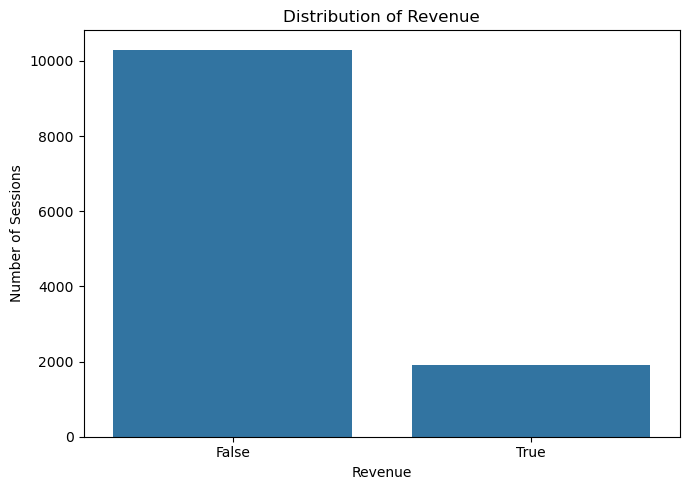

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Revenue")

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.tight_layout()
plt.show()

### Observation

The target distribution shows that non-purchasing sessions are substantially more numerous than purchasing sessions. This indicates class imbalance in the target variable.

Because of this imbalance, model performance will be evaluated using multiple metrics rather than accuracy alone.

## 8. Numerical Feature Distributions

The distributions of numerical features are visualized using histograms with density curves.

These plots help identify the general shape of each feature's distribution, its range, and whether the feature contains highly concentrated or skewed values.

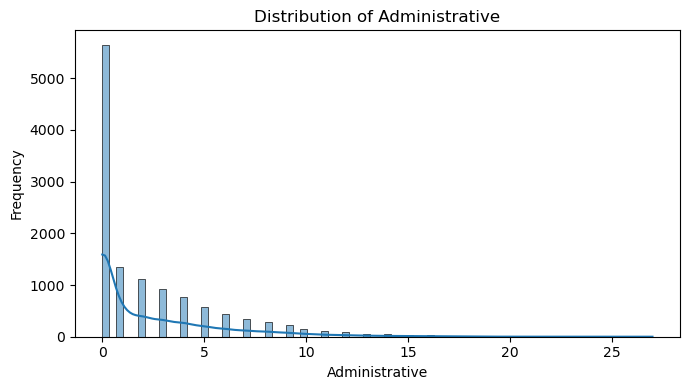

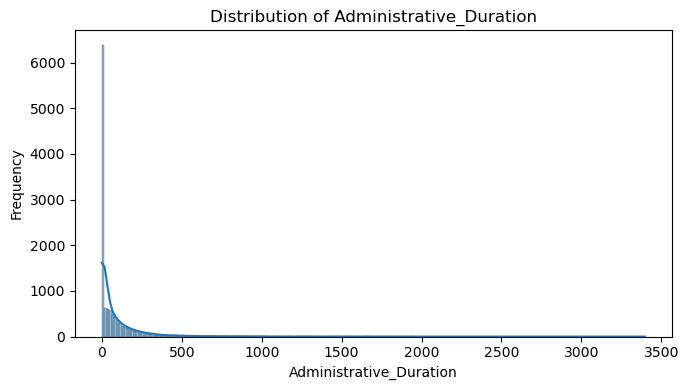

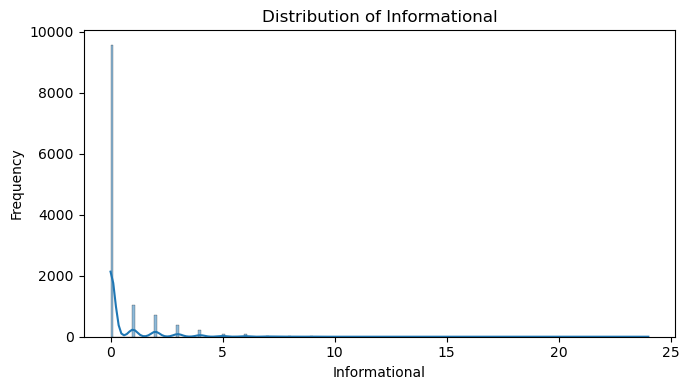

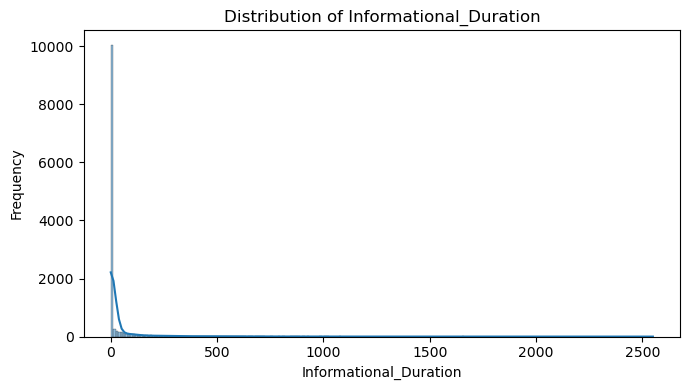

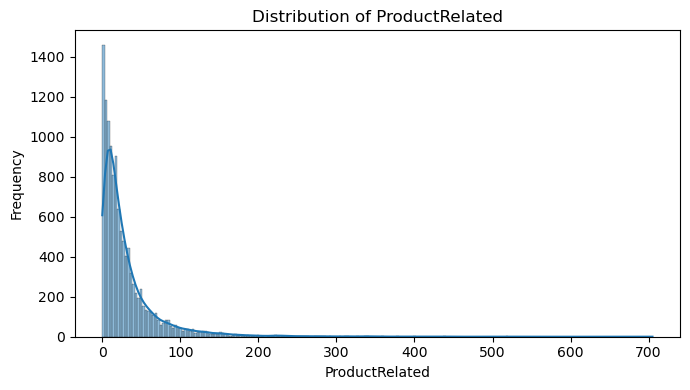

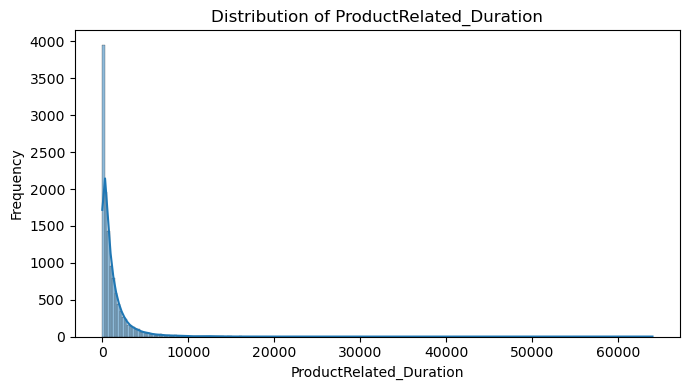

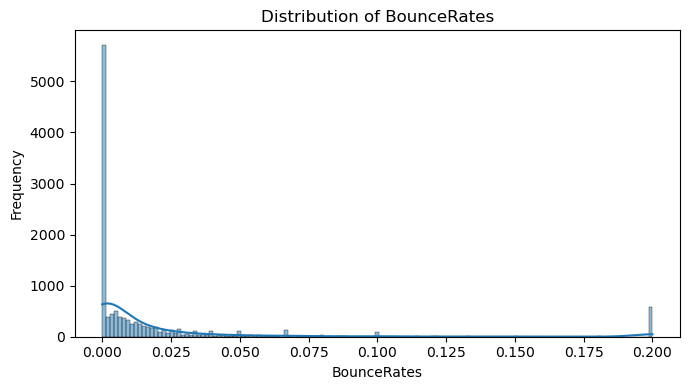

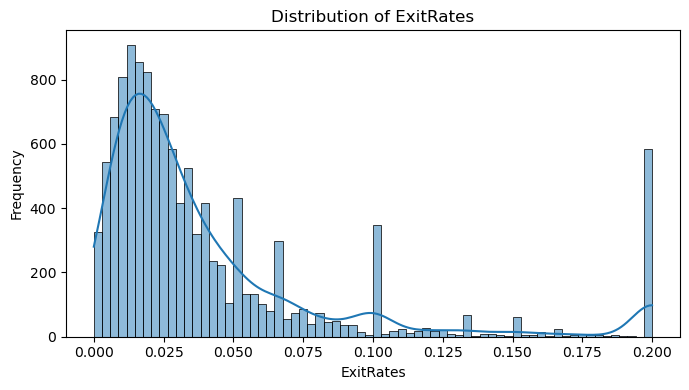

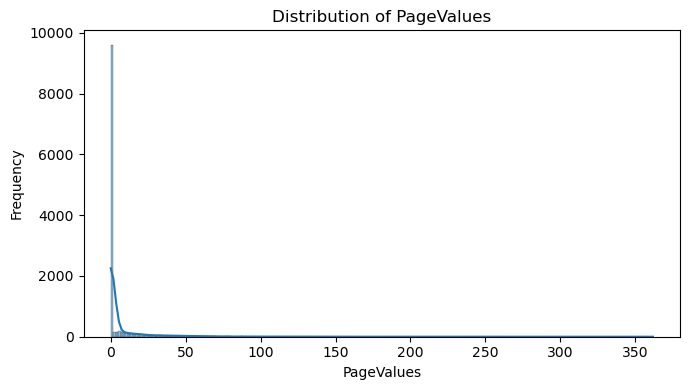

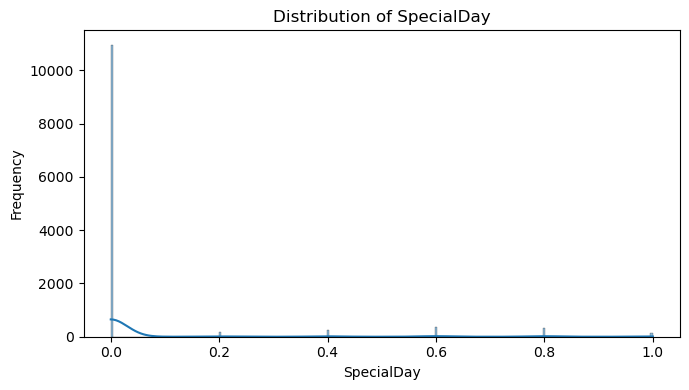

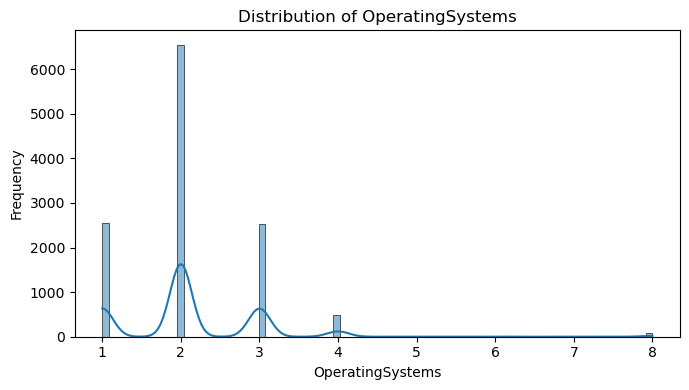

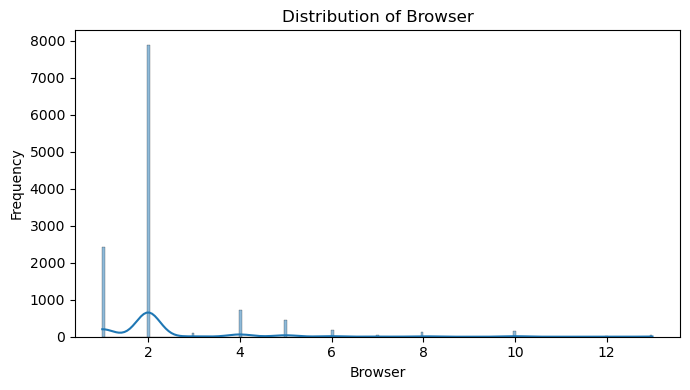

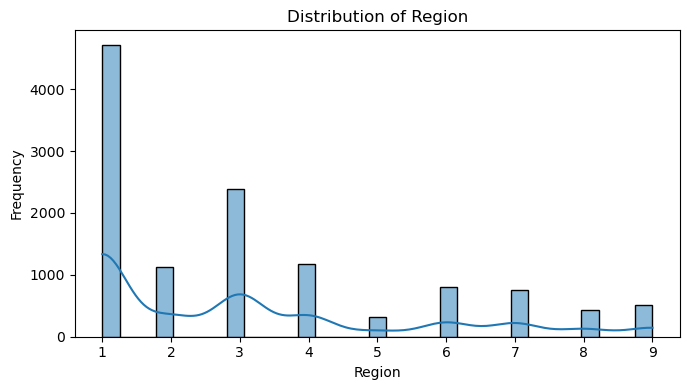

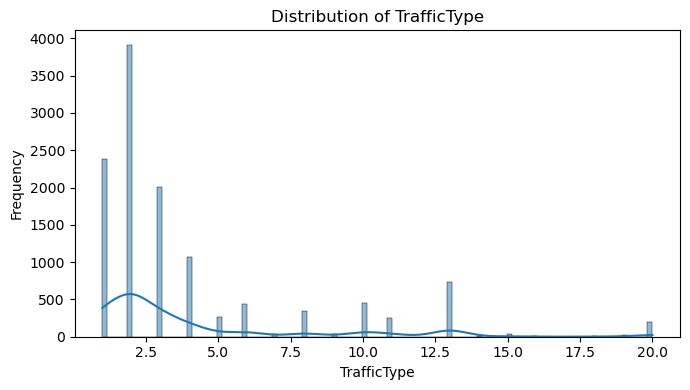

In [10]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numerical_columns:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

### Distribution Plot Observations

The distribution plots were examined to understand the behaviour and spread of the numerical features.

Features with highly concentrated values or long tails were noted because such distributions may affect distance-based algorithms and can also indicate the presence of extreme observations.

The plots were also used as part of the preliminary outlier analysis.

## 9. Categorical Feature Analysis

Categorical variables cannot be directly used by most scikit-learn machine-learning algorithms in their original string form.

The distributions of the categorical variables are first visualized so that their categories and frequencies can be understood before encoding.

In [11]:
categorical_columns = df.select_dtypes(
    include=["object", "bool"]
).columns

print("Categorical / Boolean columns:")
print(categorical_columns)

Categorical / Boolean columns:
Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')


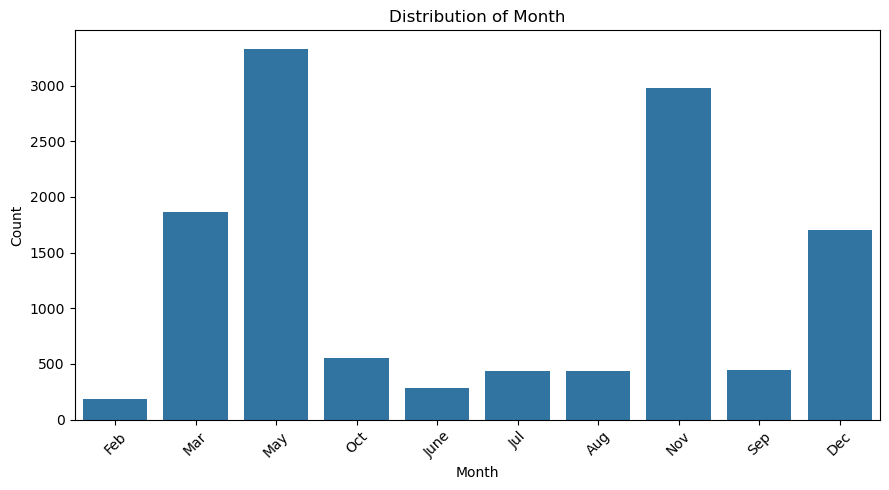

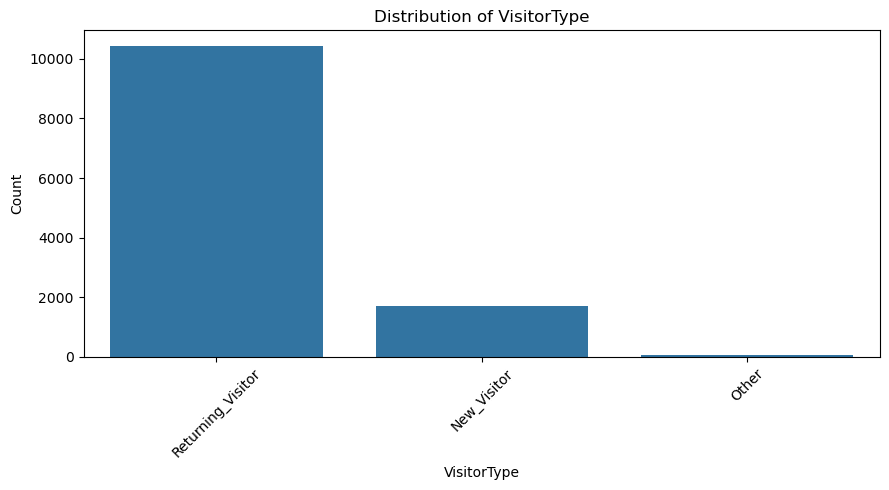

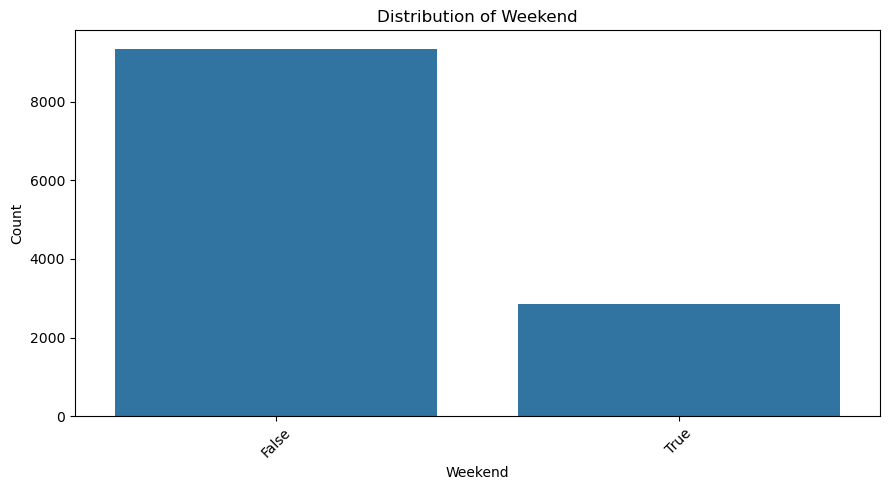

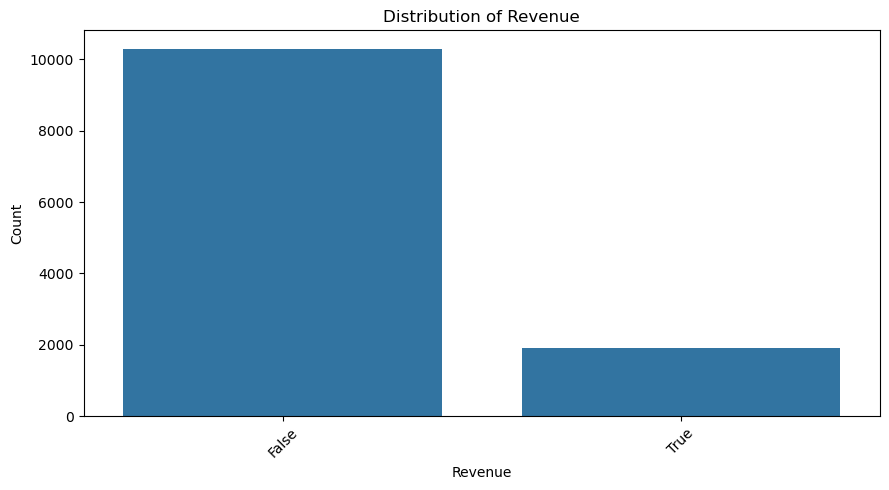

In [12]:
for column in categorical_columns:
    plt.figure(figsize=(9, 5))
    
    sns.countplot(data=df, x=column)
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 10. Correlation Analysis

A correlation matrix is created for the numerical features.

Correlation measures the strength and direction of a linear relationship between two numerical variables.

The heatmap helps identify pairs of variables that have relatively strong positive or negative relationships and provides an overview of relationships among numerical features.

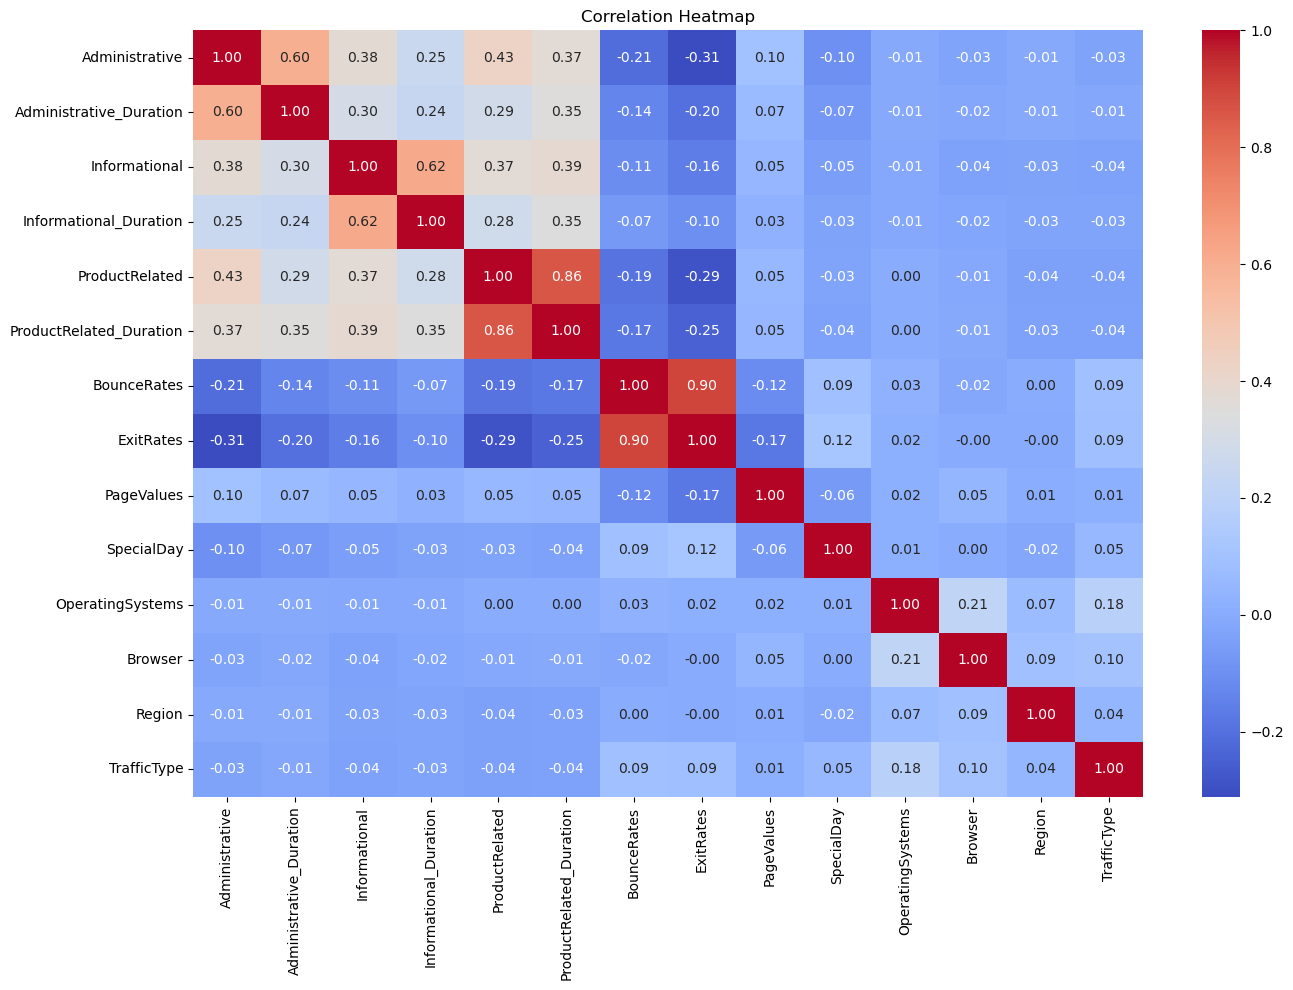

In [13]:
correlation_matrix = df.select_dtypes(
    include=["int64", "float64"]
).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Heatmap – Observation

The correlation heatmap shows the relationships between the numerical variables.

The observed relationships should be interpreted based on their correlation values. In particular, page-count variables and their corresponding duration variables may show relationships because increased browsing activity can be associated with longer session durations.

The heatmap is also useful for identifying potentially redundant information among numerical predictors.

## 11. Feature–Target Relationship Analysis

The relationship between selected numerical features and the target variable is visualized.

These plots help investigate whether purchasing and non-purchasing sessions show different patterns for important browsing-related variables.

Two representative features are selected for visualization.

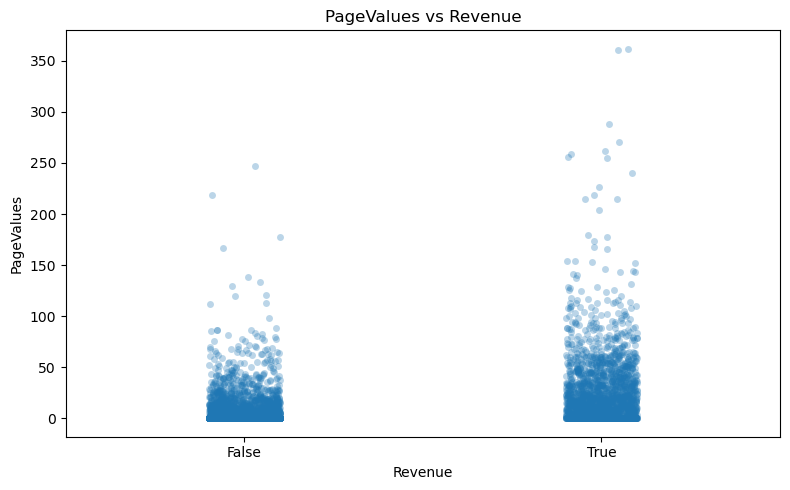

In [14]:
plt.figure(figsize=(8, 5))

sns.stripplot(
    data=df,
    x="Revenue",
    y="PageValues",
    jitter=True,
    alpha=0.3
)

plt.title("PageValues vs Revenue")
plt.xlabel("Revenue")
plt.ylabel("PageValues")

plt.tight_layout()
plt.show()

### Observation – PageValues vs Revenue

The plot is used to compare the distribution of `PageValues` between purchasing and non-purchasing sessions.

The observed separation or overlap between the two groups provides an indication of whether this feature may contain useful information for predicting `Revenue`.

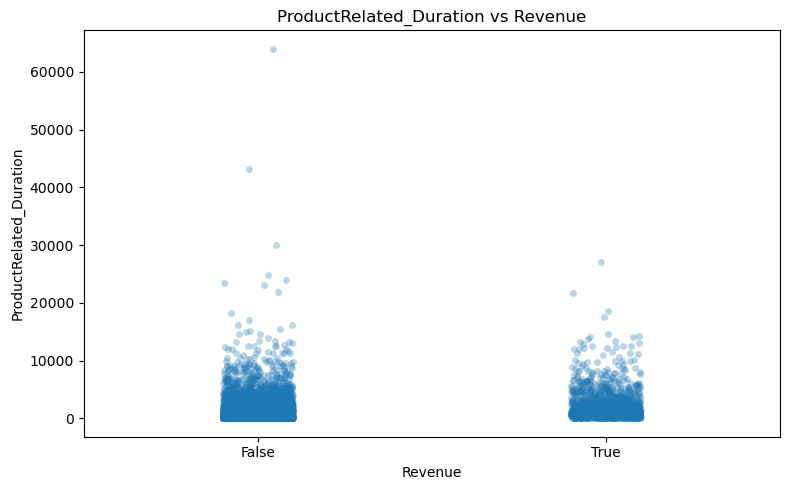

In [15]:
plt.figure(figsize=(8, 5))

sns.stripplot(
    data=df,
    x="Revenue",
    y="ProductRelated_Duration",
    jitter=True,
    alpha=0.3
)

plt.title("ProductRelated_Duration vs Revenue")
plt.xlabel("Revenue")
plt.ylabel("ProductRelated_Duration")

plt.tight_layout()
plt.show()

### Observation – ProductRelated_Duration vs Revenue

The plot compares product-related browsing duration across the two revenue classes.

The amount of overlap and the differences between the two groups provide an initial indication of whether `ProductRelated_Duration` may help distinguish purchasing sessions from non-purchasing sessions.

## 12. Outlier Analysis

Potential outliers in numerical features are investigated using boxplots.

An outlier identified by a statistical visualization is not automatically considered an erroneous observation. In an online shopping dataset, unusually high browsing counts or durations may represent legitimate user behaviour.

Therefore, the observations are inspected before deciding whether removal is appropriate.

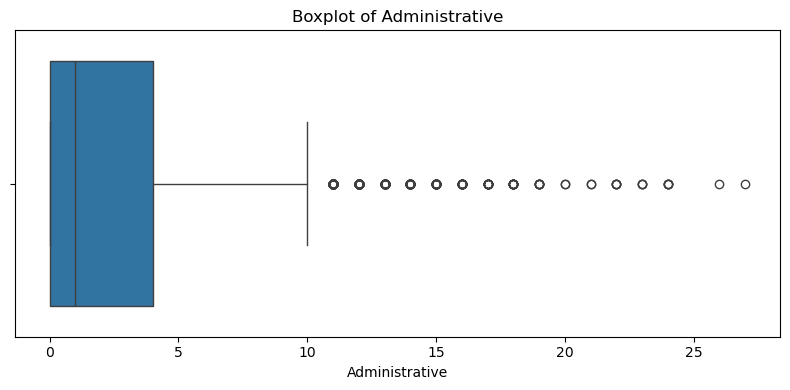

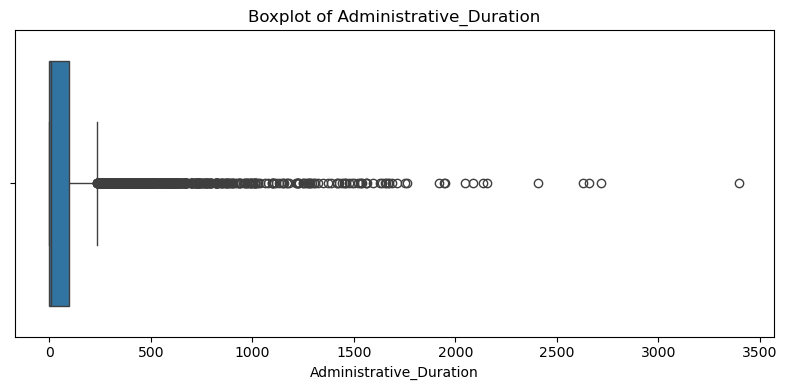

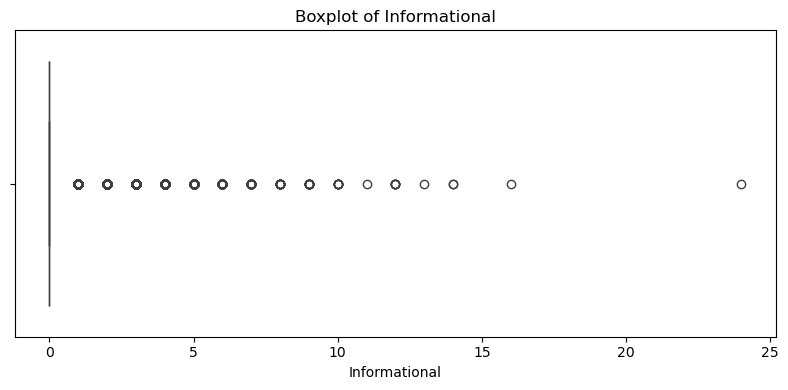

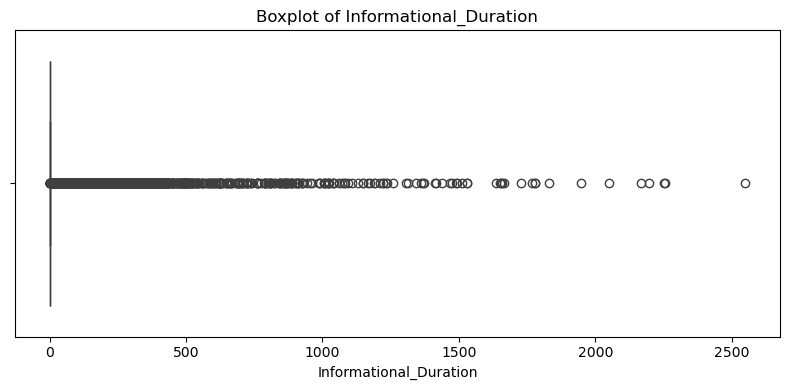

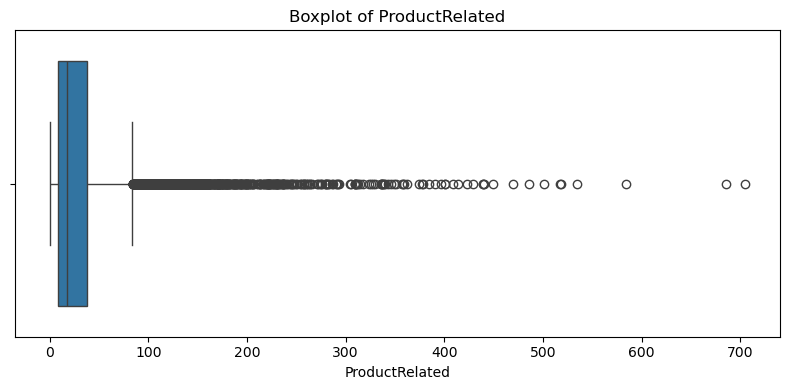

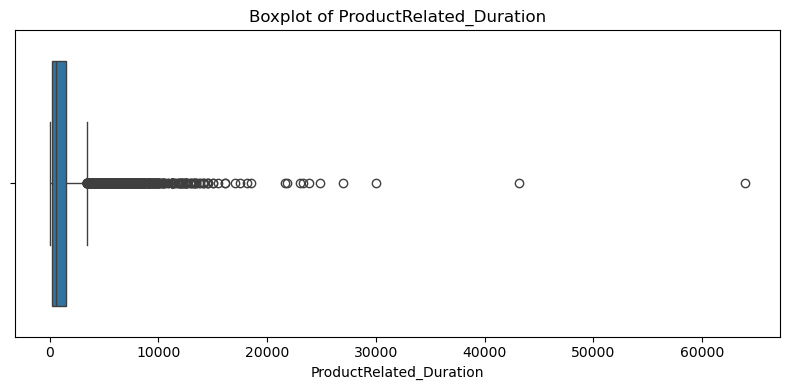

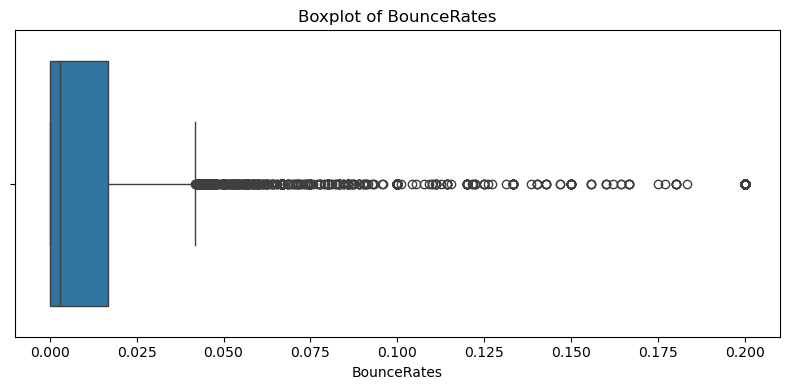

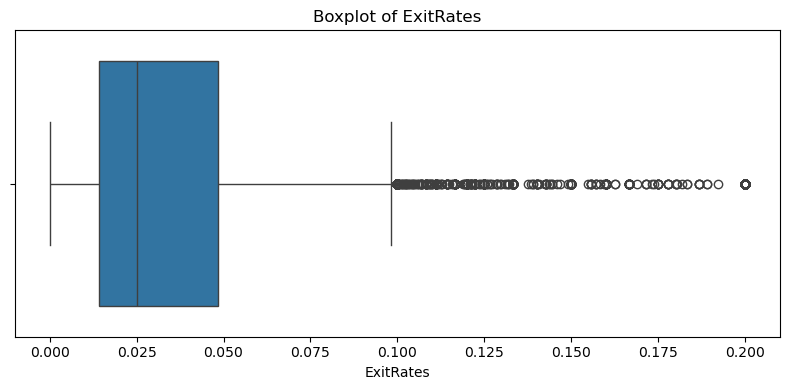

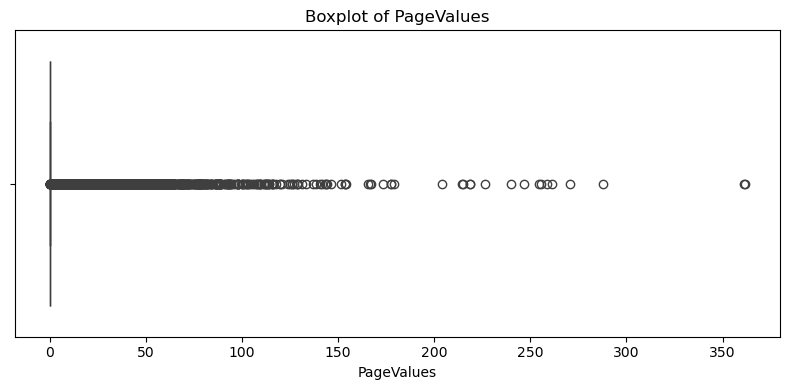

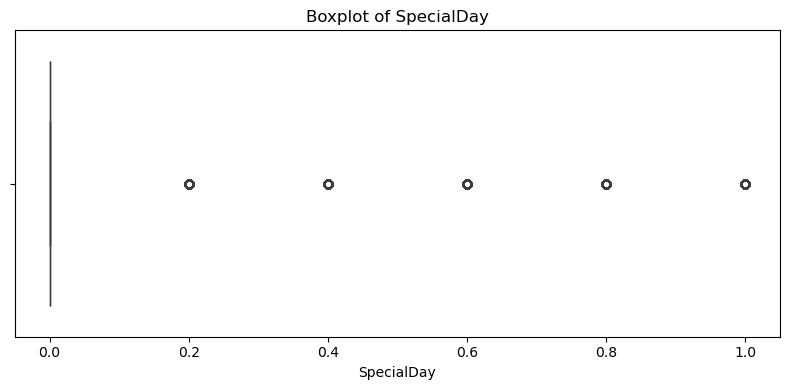

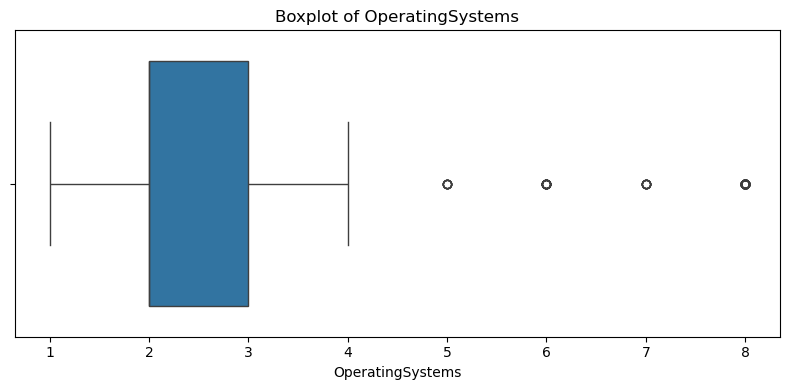

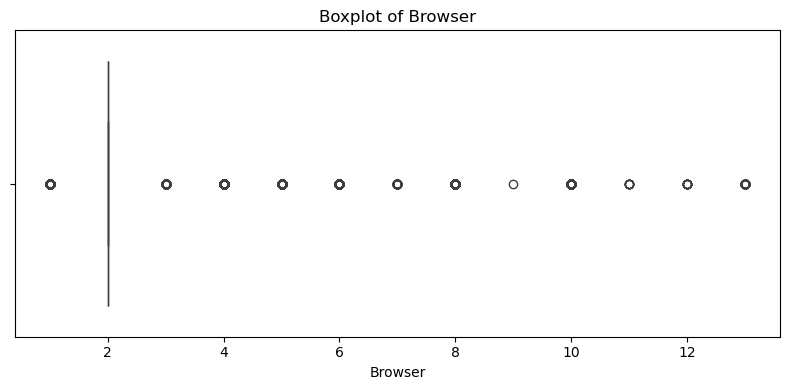

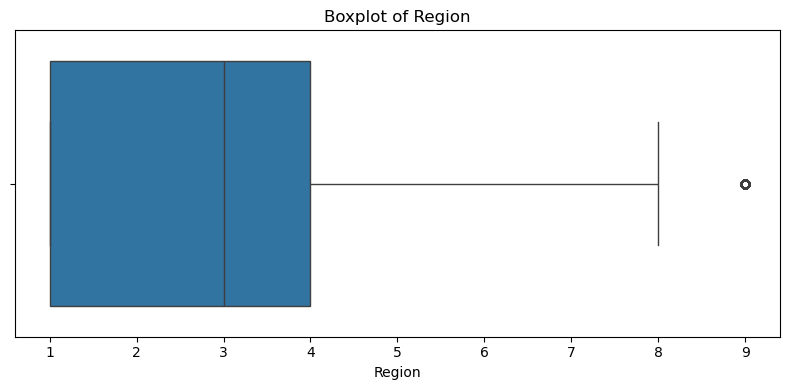

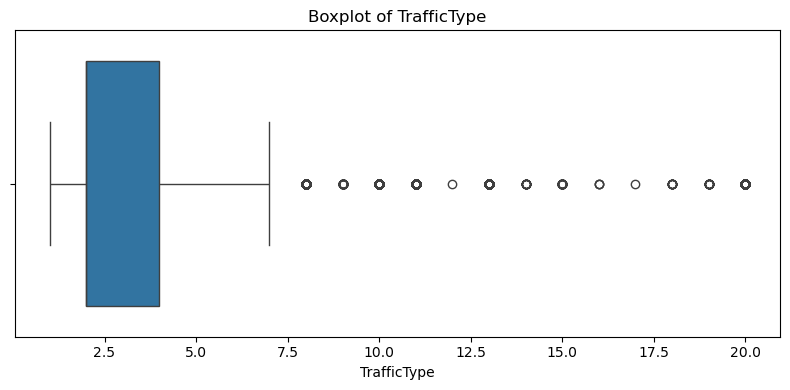

In [16]:
for column in numerical_columns:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df[column])
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

### Outlier Treatment – Observation

The boxplots were examined for potentially extreme observations.

Extreme values were treated cautiously because unusually long browsing sessions or high page counts can represent legitimate shopping behaviour rather than data-entry errors. Therefore, observations were not removed solely because they appeared beyond the boxplot whiskers.

## 13. Feature Engineering

At least one new feature is created to satisfy the feature-engineering requirement.

A new feature called `TotalPages` is created by combining the number of Administrative, Informational, and ProductRelated pages visited during a session.

This feature provides a single measure representing the overall number of pages visited across these three page categories.

In [17]:
df["TotalPages"] = (
    df["Administrative"]
    + df["Informational"]
    + df["ProductRelated"]
)

df[
    [
        "Administrative",
        "Informational",
        "ProductRelated",
        "TotalPages"
    ]
].head()

,Administrative,Informational,ProductRelated,TotalPages
0,0,0,1,1
1,0,0,2,2
2,0,0,1,1
3,0,0,2,2
4,0,0,10,10


### Feature Engineering Justification

`TotalPages` summarizes the overall page-view activity during a shopping session.

The feature may help classification models capture the overall level of browsing activity without requiring the model to combine the three page-count variables independently.

## 14. Define Features and Target

The dataset is divided into:

- `X`: predictor variables used by the models.
- `y`: target variable that the models attempt to predict.

`Revenue` is removed from `X` because it is the output variable.

The Boolean target is converted into numerical labels:
- `False → 0`
- `True → 1`

In [18]:
X = df.drop("Revenue", axis=1)

y = df["Revenue"].astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (12205, 18)
Target shape: (12205,)


## 15. Identify Numerical and Categorical Features

The predictor variables are separated into numerical and categorical groups.

Numerical variables will be scaled using `StandardScaler`.

Categorical variables will be converted into numerical representations using one-hot encoding.

This separation allows the appropriate preprocessing method to be applied to each feature type.

In [20]:
categorical_features = X.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Month', 'VisitorType', 'Weekend']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'TotalPages']


## 16. Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 split.

The training data is used to learn the model, while the test data is kept separate for final evaluation.

`stratify=y` is used because the target classes are imbalanced. This helps maintain approximately the same class distribution in both subsets.

A random state of 42 is used to make the split reproducible.

The same split will be used for all five classification algorithms so that their performance can be compared fairly.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 9764
Testing samples: 2441


## 17. Encoding and Feature Scaling

Machine-learning algorithms require numerical input.

One-hot encoding is used for categorical variables because it represents each category as a separate binary feature.

StandardScaler is applied to numerical variables so that features with different numerical ranges are placed on comparable scales.

The preprocessing is included inside a pipeline/ColumnTransformer. This is important because the encoder and scaler must be fitted using the training data only. Applying preprocessing to the complete dataset before splitting would cause data leakage.

Scaling is particularly important for Logistic Regression, KNN, and SVM because these algorithms can be sensitive to feature magnitude.